### Selenium
- 웹어플리케이션의 테스트를 자동화할 수 있도록 설계된 오픈 소스
- 실제 웹 브라우저를 열고 사용자가 동작하는 것처럼 웹 페이지를 조작
- JavaScript 기반으로 동적 콘텐츠 처리 가능
- WebDriver를 이용하여 브라우저를 제어하여 일부 웹사이트는 차단될 수 있음
- 동적 콘텐츠 및 브라우저 조작이 필요한 사이트에 유용
- 브라우저를 사용하는 방식으로 느리고, 서버에 많은 부하를 줄 수 있음

#### selenium 동작과정
1. WebDriver 객체 생성: 특정 브라우저를 제어할 수 있는 객체를 생성
2. 웹 페이지 열기: get() 메서드를 통해 URL을 통해 웹 페이지 로드 -> request
3. 요소 찾기: 다양한 방법으로 페이지 내에서 요소 찾기 -> selector, request.css(),xpath.get()
4. 상호작용: 텍스트 입력, 클릭 등 다양한 작업 수행
5. 대기: 요소가 로드되거나 특정 조건이 만족될 때까지 대기
6. 브라우저 종료: 작업이 끝난 후 quit() 메서드를 호출하여 브라우저 종료

[Selenium Cheat Sheet](https://intellipaat.com/blog/tutorial/selenium-tutorial/selenium-cheat-sheet/)

##### selenium, webdriver 설치 및 세션 시작

In [ ]:
#코랩 기반이기 때문에 크롬 설치

In [ ]:
%%capture
# Chrome 및 ChromDriver 설치
!apt-get update --pp    #패키지 목록 업데이트(출력 최소화)
!apt-get --qqy wget unzip   #wget과 upzip 패키지 설치
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb  #최신 Chrome 다운로드
!dpkg -i google-chrome-stable_current_amd64.deb  #Chrome 설치
!apt --fix-broken install -y    #설치 중 발생하는 문제 해결
!pip install webdriver-manager  #webdriver-manager설치
!pip install selenium           #selenium 설치

##### 1. WebDriver 객체 생성

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

# webdriver-manager를 이용하여 최신 ChromDriver 설치
driver_path = ChromeDriverManager().install()
print(f"Chrome Driver installed at {driver_path}")  #Driver 설치 경로 출력

# Chrome 옵션 설정(브라우저창없이 백그라운드에서 실행)
options = webdriver.ChromeOptions()
# 코랩에서 지원 안되어서 --headless 넣은것 원래 필요 없음
options.add_argument('--headless')              #GUI없이 실행(Colab 환경에서는 GUI 지원이 안됨)
options.add_argument('--no-sandbox')            #샌드박스 모드 비활성화
options.add_argument('--disable-dev-shm-usage') #dev/shm 사용 비활성화
options.add_argument('--start-maximized')       #브라우저창 최대화

# ChromDriver 자동 설치 및 실행
service = Service(driver_path)
driver = webdriver.Chrome(service=service, options=options)

ModuleNotFoundError: No module named 'selenium'

##### 2. 웹 페이지 열기

In [ ]:
# 페이지 접속, 상호작용
# driver 자체가 브라우저 움직이는 용도이기 때문에 이용해 사이트 가져옴
driver.get("https://www.google.com")
driver.back()
driver.forward()
driver.refresh()

In [ ]:
# 페이지 정보 가져오기
title = driver.title
url = driver.current_url
handle = driver.current_window_handle # 현재 창에 대한 번호
title, url, handle

('Google', 'https://www.google.com/', 'D6A4976345F1859B38D1363F6597D6BB')

##### 3. 요소 찾기 (element finder)
- 로케이터를 활용하여 찾기

    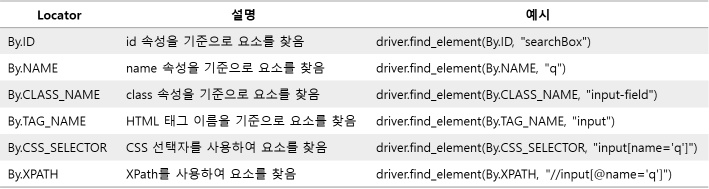

- 위치 로케이터를 이용하여 찾기

    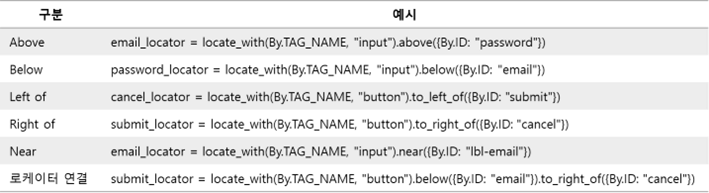


In [ ]:
# find_elements : 전체요소
# find_element(by=..) : 첫번째 요소

# 위치 로케이터 마지막줄 예시 설명
# email 밑에 cancel 버튼 기준 오른쪽에 있는 버튼의 이름을 가져와라

In [ ]:
from selenium.webdriver.common.by import By

text_box = driver.find_element(by=By.NAME, value="my-text")
submit_button = driver.find_element(by=By.CSS_SELECTOR, value="button")

# 첫번째 일치하는 요소
driver.find_element(By.XPATH, '//button[text()="Some text"]')
driver.find_element(By.XPATH, '//button')
driver.find_element(By.ID, 'loginForm')
driver.find_element(By.LINK_TEXT, 'Continue')
driver.find_element(By.PARTIAL_LINK_TEXT, 'Conti')
driver.find_element(By.NAME, 'username')
driver.find_element(By.TAG_NAME, 'h1')
driver.find_element(By.CLASS_NAME, 'content')
driver.find_element(By.CSS_SELECTOR, 'p.content')

# 일치하는 모든 요소
plants = driver.find_elements(By.TAG_NAME, "li")

# 모든 요소 리스트에서 각 요소 가져오기
elements = driver.find_elements(By.TAG_NAME, 'p')
for e in elements:
    print(e.text)

# 요소에서 요소찾기
# 첫번째 div를 가져와서 그 밑의 p들을 모두 가져오기
element = driver.find_element(By.TAG_NAME, 'div')
elements = element.find_elements(By.TAG_NAME, 'p')
for e in elements:
    print(e.text)

# 활성 요소 (현재 포커스가 있는)
attr = driver.switch_to.active_element.get_attribute("title")

NoSuchElementException: Message: no such element: Unable to locate element: {"method":"css selector","selector":"[name="my-text"]"}
  (Session info: chrome=132.0.6834.159); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#no-such-element-exception
Stacktrace:
#0 0x56f15e0d753a <unknown>
#1 0x56f15dbd2f00 <unknown>
#2 0x56f15dc22c0c <unknown>
#3 0x56f15dc22e31 <unknown>
#4 0x56f15dc68bd4 <unknown>
#5 0x56f15dc475cd <unknown>
#6 0x56f15dc65f84 <unknown>
#7 0x56f15dc47343 <unknown>
#8 0x56f15dc1478a <unknown>
#9 0x56f15dc159de <unknown>
#10 0x56f15e0a12cb <unknown>
#11 0x56f15e0a5242 <unknown>
#12 0x56f15e08e7ac <unknown>
#13 0x56f15e0a5df7 <unknown>
#14 0x56f15e072b2f <unknown>
#15 0x56f15e0c61a8 <unknown>
#16 0x56f15e0c6370 <unknown>
#17 0x56f15e0d63b6 <unknown>
#18 0x7d4527d52ac3 <unknown>


##### 4. 상호작용
- 요소와 상호작용

    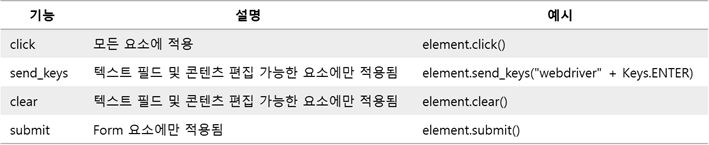

- 요소의 정보

    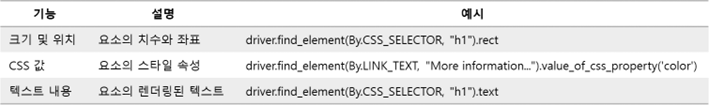

In [ ]:
search_box = driver.find_element("name", "q")  # 검색창 찾기
search_box.send_keys("Selenium")  # 텍스트 입력
search_box.submit()  # Enter 키 누르기
result = driver.find_element("tag name", "h3").text  # 검색 결과의 제목 가져오기
print(result)

MaxRetryError: HTTPConnectionPool(host='localhost', port=53047): Max retries exceeded with url: /session/ab8dccf609b39557a5d4dea281e544be/element (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x785dc85bb950>: Failed to establish a new connection: [Errno 111] Connection refused'))

In [ ]:
# JavaScript 실행
header = driver.find_element(By.CSS_SELECTOR, "h1")
# header를 arguments에다가 넣어줌
driver.execute_script('return arguments[0].innerText', header)

##### iFrame

In [1]:
# iFrame을 대상으로 드라이버 전환하여 상호작용
iframe = driver.find_element(By.CSS_SELECTOR, "#modal > iframe")
driver.switch_to.frame(iframe)
driver.find_element(By.TAG_NAME, 'button').click()

# 이름 또는 ID를 사용하여 전환
driver.switch_to.frame('buttonframe')

# 인덱스를 사용하여 전환
iframe = driver.find_elements(By.TAG_NAME,'iframe')[1]
driver.switch_to.frame(iframe)

# iFrame 나가 기본 콘텐츠로 돌아가기
driver.switch_to.default_content()

##### 팝업창

In [ ]:
from selenium.webdriver.common.alert import Alert

wait = WebDriverWait(driver, 10)

# Alert
driver.find_element(By.LINK_TEXT, "See an example alert").click()
alert = wait.until(EC.alert_is_present()) # alert가 생겼다면 보여질 때까지 기다려라
text = alert.text
alert.accept()  #확인버튼 클릭

# Confirm
driver.find_element(By.LINK_TEXT, "See a sample confirm").click()
wait.until(EC.alert_is_present())
alert = driver.switch_to.alert
text = alert.text
alert.dismiss() #취소버튼 클릭

# Prompt
driver.find_element(By.LINK_TEXT, "See a sample prompt").click()
wait.until(EC.alert_is_present())
alert = Alert(driver)
alert.send_keys("Selenium")
alert.accept()

# 팝업창
driver.switch_to.window(driver.window_handles[1])
driver.close()   # 각각 종료
driver.switch_to.window(driver.window_handles[0])
driver.close()   # 각각 종료

##### 5. 대기

In [ ]:
# 대기시간 처리
import time
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC #특정조건이 나올 때까지

# 10초 동안 대기
time.sleep(10)

# 필요한 요소가 로드될 때 까지 대기 (tag가 p인 요소가 로드될 때까지 최대 10초 대기)
WebDriverWait(driver, timeout=10).until(EC.presence_of_element_located((By.TAG_NAME,"p")))

##### 6. 브라우저 종료

In [ ]:
driver.quit()

# Chrome 및 ChromeDriver 프로세스 종료
!pkill chrome
!pkill chromedriver

#### selenium을 활용한 크롤링 예제
- coffeebean 매장정보

In [2]:
import pandas as pd
from selenium.webdriver.common.by import By
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
# 웹페이지 연결
driver.get("https://www.coffeebeankorea.com/store/store.asp")
print(driver.title)

# 1번부터 400번 매장 정보 추출
result = []
for i in range(1, 400):
    try:
        # i 는 매장번호
        # 사이트 자세히보기버튼에 javascript코드가 storePop2로 되어있기 때문
        driver.execute_script(f"storePop2('{i}');")
        # matizCoverLayer가 생길 때까지 최대 10초 대기
        layer = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, ".matizCoverLayer")))
        # matizCoverLayer에서 정보 추출
        store_name = layer.find_element(By.CSS_SELECTOR, "div.store_txt > h2").text
        print(store_name)  #매장 이름 출력하기
        store_details = layer.find_elements(By.CSS_SELECTOR, "table.store_table > tbody > tr > td")
        store_time = store_details[0].text
        store_address = store_details[2].text
        store_phone = store_details[3].text
        result.append([store_name] + [store_address] + [store_phone] + [store_time])
        driver.refresh()  # 레이어 변수 초기화
    except:
        continue

# CSV 파일로 저장
CB_tbl = pd.DataFrame(result, columns=('store', 'address','phone', 'time'))
CB_tbl.to_csv('CoffeeBean.csv', encoding='utf-8', index=True)

In [ ]:
import pandas as pd
from selenium.webdriver.common.by import By
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
# 웹페이지 연결
driver.get("https://www.coffeebeankorea.com/store/store.asp")
print(driver.title)

# 1번부터 400번 매장 정보 추출
result = []
for i in range(1, 400):
    try:
        driver.execute_script(f"storePop2('{i}');")
        # matizCoverLayer가 생길 때까지 최대 10초 대기
        layer = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, ".matizCoverLayer")))
        # matizCoverLayer에서 정보 추출
        store_name = layer.find_element(By.CSS_SELECTOR, "div.store_txt > h2").text
        print(store_name)  #매장 이름 출력하기
        store_details = layer.find_elements(By.CSS_SELECTOR, "table.store_table > tbody > tr > td")
        store_time = store_details[0].text
        store_address = store_details[2].text
        store_phone = store_details[3].text
        result.append([store_name] + [store_address] + [store_phone] + [store_time])
        driver.refresh()  # 레이어 변수 초기화
    except:
        continue

# CSV 파일로 저장

CB_tbl = pd.DataFrame(result, columns=('store', 'address','phone', 'time'))
CB_tbl.to_csv('CoffeeBean.csv', encoding='utf-8', index=True)

####[실습] Selenium 실습
조별 자유주제로, Selenium 실습